<a href="https://colab.research.google.com/github/greeshmapj/AI-course-notes/blob/main/Sec12_outlier_handling_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **OUTLIER HANDLING**

# What is an Outlier?

An outlier is a data point that is very different from the rest of the data.

📌 It lies far away from most values in a dataset.


An outlier is an observation that deviates significantly from other observations in the dataset.

In [1]:
import seaborn as sns
sns.load_dataset('mpg')

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
394,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
395,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
396,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [2]:
import pandas as pd

x = pd.Series([1,2,3,4,5,8,10,2,3,6,100, -50]) #single column

# Skewness using pandas
x
# mean , median , skew, box plot

import statistics  as st
print("mean",st.mean(x))
print("median",st.median(x))

mean 7.833333333333333
median 3.5


mean > median  # positvely skewed

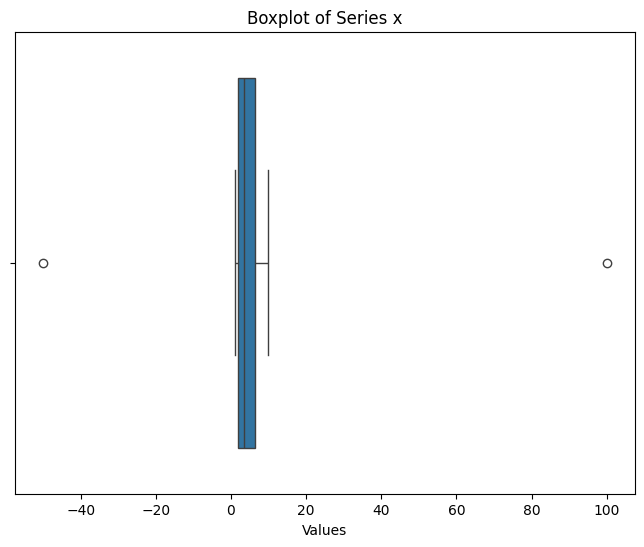

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.boxplot(x=x)
plt.title('Boxplot of Series x')
plt.xlabel('Values')
plt.show()

In [4]:
x.skew() # skew=  must be 0- symmetrical, normal

np.float64(1.7746698661479865)

In [5]:
x.describe()

,0
count,12.000000
mean,7.833333
std,33.072464
min,-50.000000
25%,2.000000
50%,3.500000
75%,6.500000
max,100.000000


In [6]:
Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1

print("Q1: ", Q1)
print("Q3: ", Q3)
print("IQR: ", IQR)

Q1:  2.0
Q3:  6.5
IQR:  4.5


In [7]:


lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound: ", lower)
print("Upper bound: ", upper)


Lower bound:  -4.75
Upper bound:  13.25


In [8]:
x

,0
0,1
1,2
2,3
3,4
4,5
5,8
6,10
7,2
8,3
9,6


In [9]:
# remove outliers
x_clean =x[(x >= lower) & (x <= upper)]
print("clean",x_clean)

# try to print outliers

x_outlier = x[(x<lower) | (x>upper)]
print("outlier",x_outlier)

clean 0     1
1     2
2     3
3     4
4     5
5     8
6    10
7     2
8     3
9     6
dtype: int64
outlier 10    100
11    -50
dtype: int64


In [10]:
x_clean.skew()

np.float64(0.9003640254375842)

<Axes: >

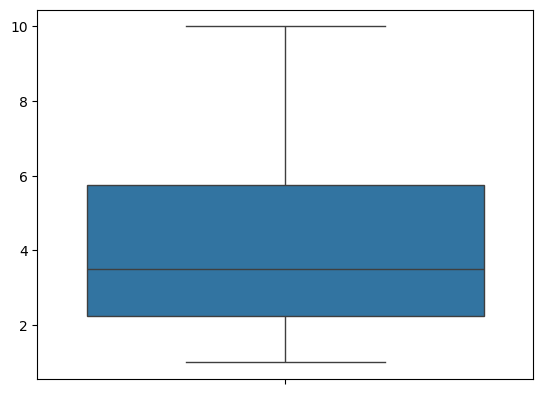

In [11]:
sns.boxplot(x_clean)

In [12]:
x

,0
0,1
1,2
2,3
3,4
4,5
5,8
6,10
7,2
8,3
9,6


In [13]:
# data loss,
#plan B-CLIPPING

In [14]:
x_clip=x.clip(lower, upper)
x_clip

,0
0,1.00
1,2.00
2,3.00
3,4.00
4,5.00
5,8.00
6,10.00
7,2.00
8,3.00
9,6.00


In [15]:
x_clip.skew()

np.float64(0.10827464954289714)

<Axes: >

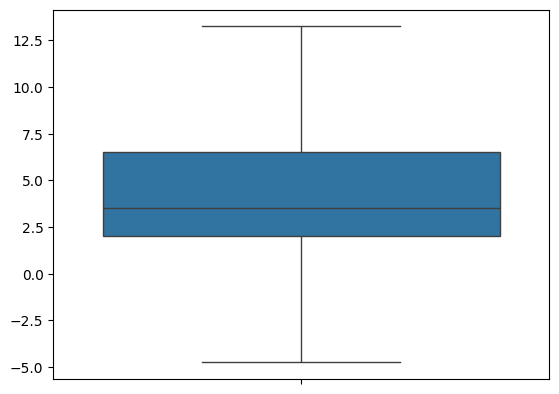

In [16]:
sns.boxplot(x_clip)

In [17]:
x #raw sdardata
x_clean #data loss
x_clip #capped data

,0
0,1.00
1,2.00
2,3.00
3,4.00
4,5.00
5,8.00
6,10.00
7,2.00
8,3.00
9,6.00
